# S4 — analiza sistematičnih parametrskih preizkusov

## Kako se ta zvezek uporablja in kaj točno dela

**Kaj dela.** Zvezek je analitična plast nad enotno tabelo rezultatov
(`docs/REZULTATI_SHEMA.md`): prebere `reports/results_master.csv` (ali jo sam
zlepi iz posameznih `results/**/results.csv`, če glavna tabela še ne obstaja),
združi ponovitve istega eksperimenta čez semena v povprečje s 95-odstotnim
Studentovim t intervalom zaupanja, nariše štiri načrtovane slike poročila
(vodilna metrika glede na ε, glede na napadalčevo predznanje, primerjava
mehanizmov, računski čas) ter pregleda prekoračitve računskega proračuna
300 sekund na zagon napada. Slike shrani v `reports/s4_figures/` in jih
prikaže v zvezku.

**Česa ne dela.** Ničesar ne poganja in ne piše v `results/` — je samo bralec.
Eksperimente poganjaš prej v terminalu (glej `docs/RUNNING.md` §7.1):

    uv run trajguard repeat config/experiments/<ime>.yaml --seeds 1 2 3 4 5
    uv run trajguard report        # zlepi glavno tabelo (ni obvezno; zvezek jo zna sam)

**Kako ga poženeš.** Interaktivno (VS Code ali `uv run --with jupyterlab
jupyter lab`), ali headless — izvede vse celice in shrani izhode v datoteko:

    uv run jupyter nbconvert --to notebook --execute --inplace notebooks/03_s4_sweep.ipynb

**Opozorili.**

1. Zvezek in modul `trajguard.reporting.results_io`, ki ga uporablja, sta
   vezana na glave stolpcev iz `docs/REZULTATI_SHEMA.md` (`RESULTS_COLUMNS`).
   Tabela s tujo glavo je glasna napaka, ne tiho zamaknjeni stolpci — če se
   shema kdaj spremeni, je treba v istem PR posodobiti shemo, bralnik
   `results_io.py` in ta zvezek.
2. Zvezkov ne izvaja nobena avtomatika (CI požene samo `ruff`, `mypy`,
   `pytest`) — po novih zagonih ga osveži ročno z zgornjim nbconvert ukazom.


## 1 · Nastavitev in nalaganje

Poti so relativne na mapo `notebooks/`. Zvezek najprej poskusi z glavno tabelo
`reports/results_master.csv`; če je ni, jo zlepi sam z isto funkcijo, kot jo
uporablja `trajguard report` (`merge_results_tables`), zato je izid enak.


In [1]:
from pathlib import Path

import pandas as pd

from trajguard.reporting.report import merge_results_tables
from trajguard.reporting.results_io import aggregate_over_seeds, read_results_csv

RESULTS_DIR = Path("..") / "results"
REPORTS_DIR = Path("..") / "reports"
FIGURES_DIR = REPORTS_DIR / "s4_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

master = REPORTS_DIR / "results_master.csv"
if not master.exists():
    merged = merge_results_tables(RESULTS_DIR, REPORTS_DIR)
    if merged is None:
        raise FileNotFoundError(
            f"no results.csv under {RESULTS_DIR}/ — run an experiment first: "
            "uv run trajguard run <config>, or trajguard repeat <config> --seeds ..."
        )
    master = merged
records = read_results_csv(master)
print(f"{master}: {len(records)} metric rows")

..\reports\results_master.csv: 426 metric rows


## 2 · Pregled naloženih zagonov

Ena vrstica na kombinacijo (eksperiment, konfiguracija, seme): koliko družin
napadov in koliko vrstic metrik je prispeval posamezen zagon. Če tu manjka
pričakovano seme ali eksperiment, preveri `results/` in po potrebi ponovno
poženi `trajguard report`.


In [2]:
df = pd.DataFrame(
    {
        "exp_id": r.provenance.exp_id,
        "config_hash": r.provenance.config_hash,
        "seed": r.provenance.seed,
        "family": r.row.family,
        "metric": r.row.value.name,
    }
    for r in records
)
df.groupby(["exp_id", "config_hash", "seed"]).agg(
    families=("family", "nunique"), metric_rows=("metric", "size")
).reset_index()

,exp_id,config_hash,seed,families,metric_rows
0,geolife_geoind_reid_u20,2b26525a336c40c2,1,4,78
1,geolife_geoind_reid_u20,2b26525a336c40c2,2,4,78
2,geolife_geoind_reid_u20,2b26525a336c40c2,3,4,78
3,geolife_geoind_reid_u20,2b26525a336c40c2,4,4,78
4,geolife_geoind_reid_u20,2b26525a336c40c2,5,4,78
5,geolife_synth_mia_u20,2b26525a336c40c2,1,1,12
6,geolife_synth_mia_u20,2b26525a336c40c2,2,1,12
7,geolife_synth_mia_u20,2b26525a336c40c2,3,1,12


## 3 · Združevanje čez semena

Ponovitve istega eksperimenta (isti `exp_id` in `config_hash`, različna semena)
se združijo v eno vrstico na metriko: vrednost je povprečje, interval pa
**95-odstotni Studentov t interval čez ponovitve**.

**Pomembno — dve vrsti intervalov, ki se ne mešata** (`docs/RUNNING.md` §7.1):
bootstrap interval znotraj enega zagona meri negotovost prevzorčenja, interval
čez semena pa varianco med ponovitvami. Vsi grafi v tem zvezku kažejo
**izključno interval čez semena**. Eksperiment z enim samim semenom dobi
izrojen interval (točko brez razpona) — njegov bootstrap interval si oglej na
grafih posameznega zagona v `results/<eksperiment>/`.


In [3]:
agg_rows = aggregate_over_seeds(records)
print(df.groupby("exp_id")["seed"].nunique().rename("n_seeds").to_string())
print(f"{len(agg_rows)} aggregated (experiment x metric) rows")

exp_id
geolife_geoind_reid_u20    5
geolife_synth_mia_u20      3
90 aggregated (experiment x metric) rows


## 4 · Vodilna metrika glede na ε

Osrednje vprašanje poročila (§7.2): kako uspešnost napada pada z močnejšim
šumom (manjši ε). Ena slika na družino napada, os ε je logaritemska; veje brez
ε (surovi podatki, identitetni mehanizem, nezasebni generatorji) na to os ne
sodijo in so izpuščene.


by_epsilon_membership_inference.png


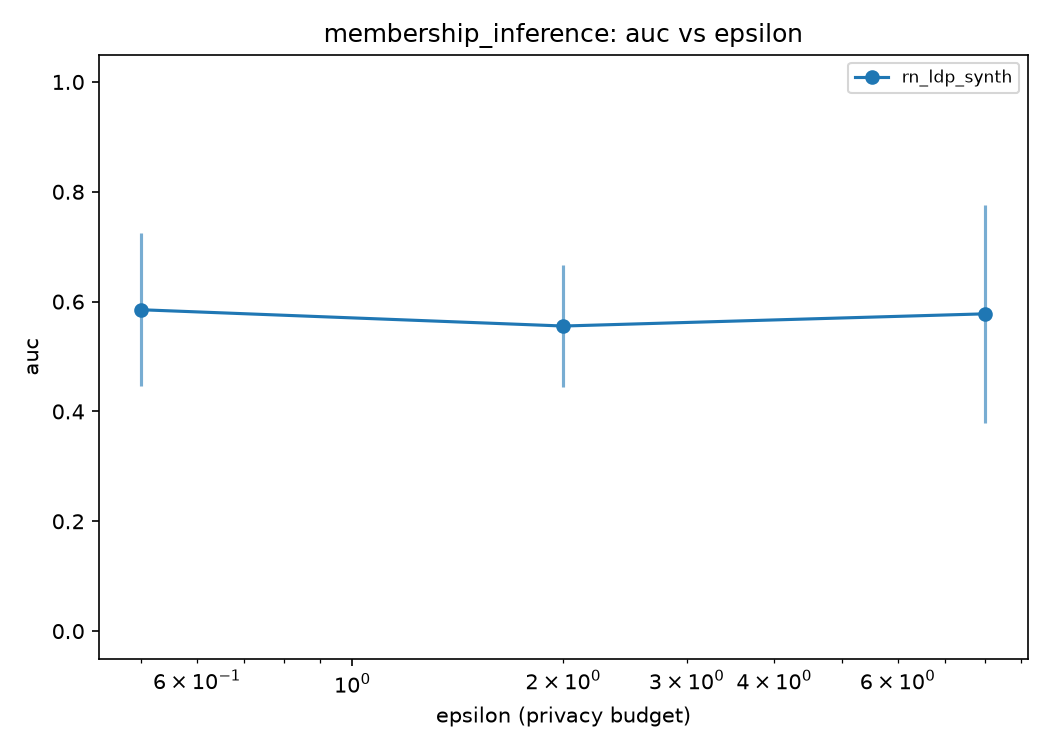

by_epsilon_poi_inference.png


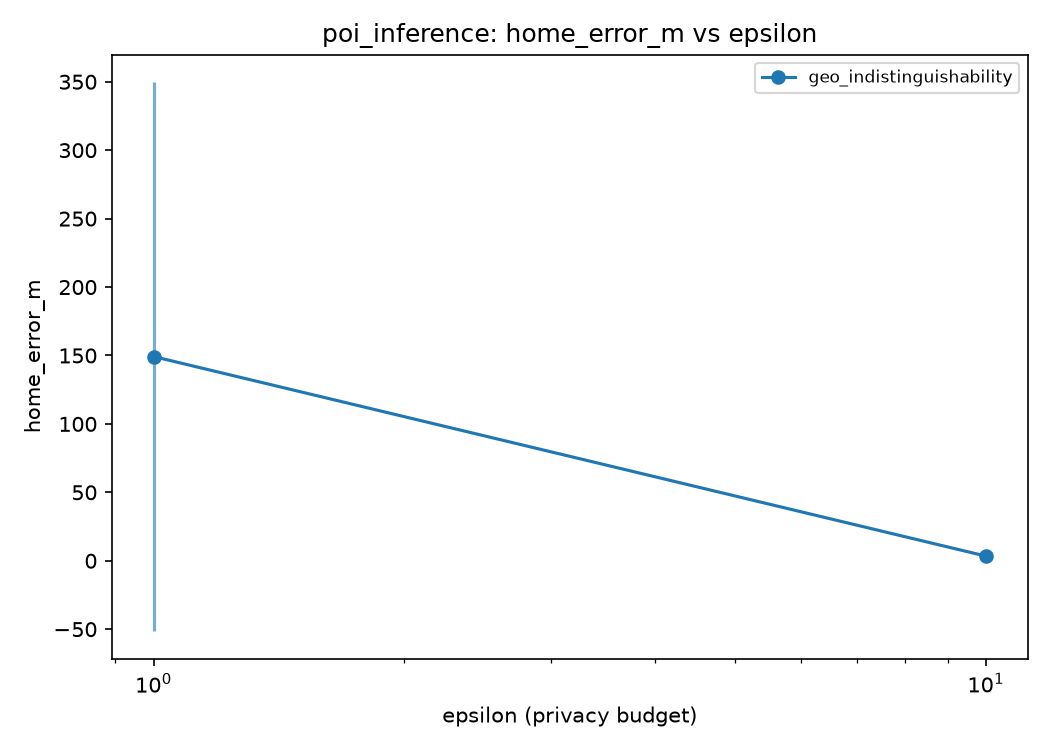

by_epsilon_reconstruction.png


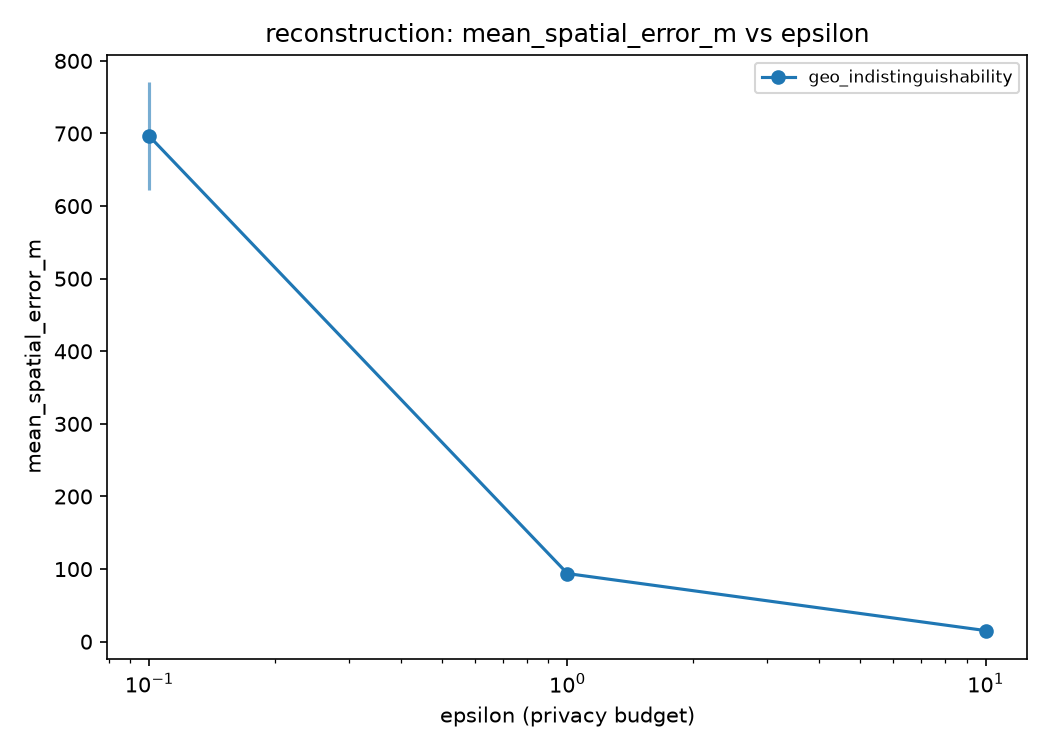

by_epsilon_reidentification.png


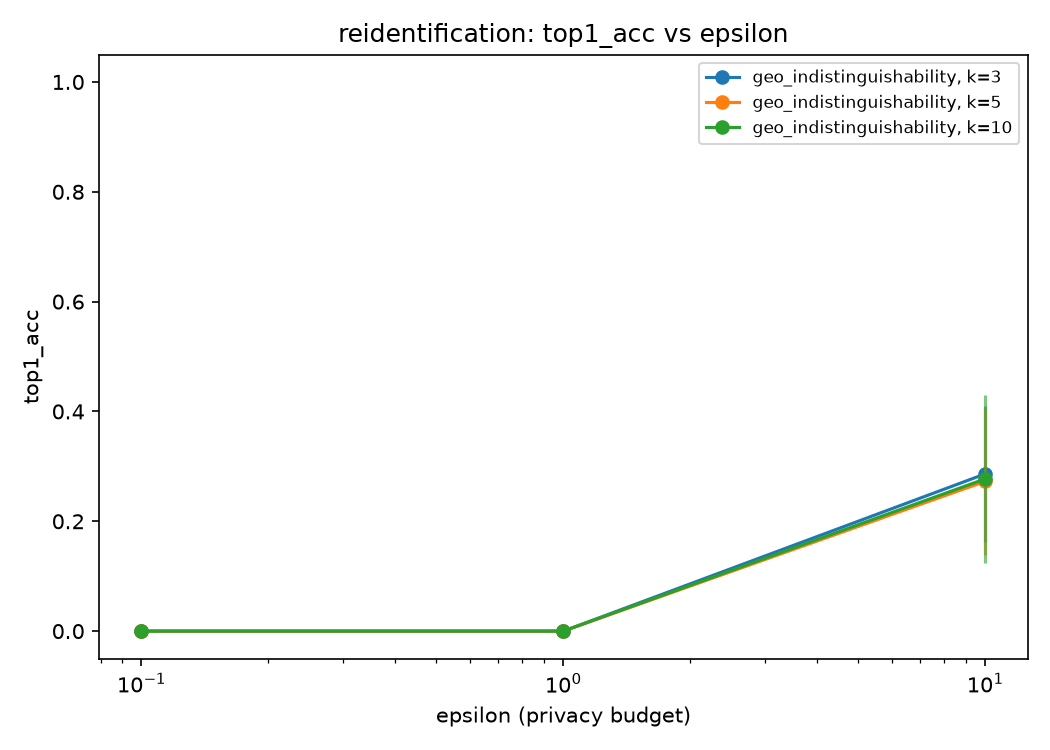

In [4]:
from IPython.display import Image, display

from trajguard.reporting.plots import (
    plot_by_epsilon,
    plot_by_knowledge,
    plot_mechanisms,
    plot_runtime,
)

for path in plot_by_epsilon(agg_rows, FIGURES_DIR):
    print(path.name)
    display(Image(filename=str(path)))

## 5 · Vpliv napadalčevega predznanja

Za družine z gumbom `known_points` (danes reidentifikacija): kako uspešnost
raste s številom točk, ki jih napadalec pozna o tarči. Ena črta na ciljno vejo.


by_knowledge_reidentification.png


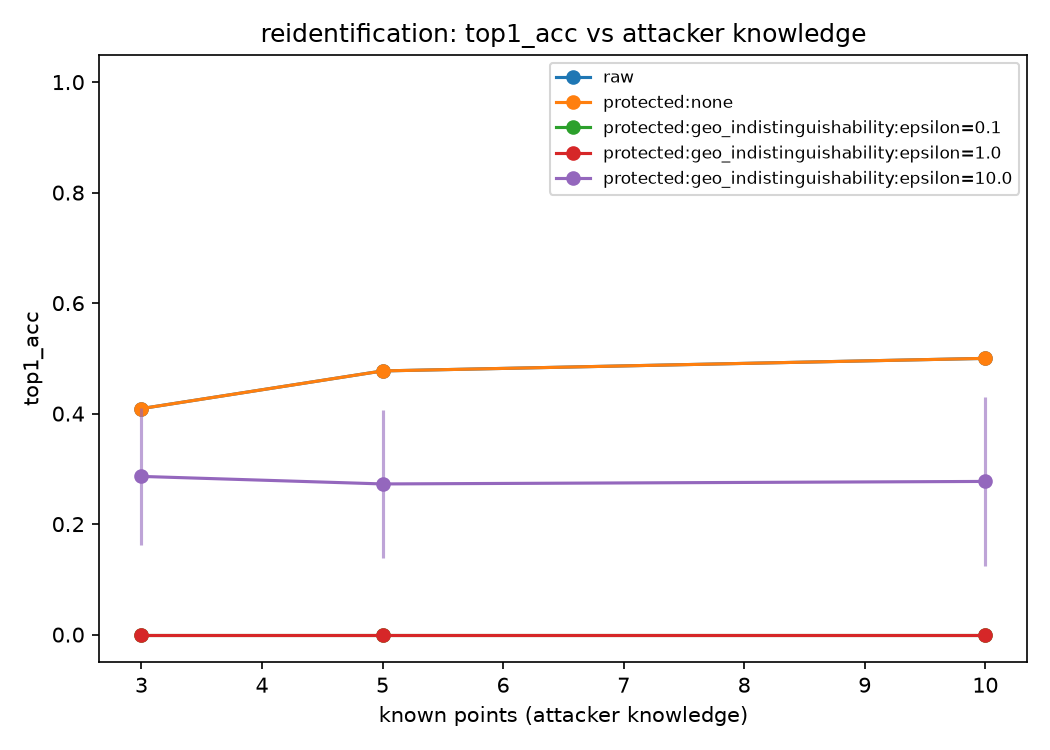

In [5]:
for path in plot_by_knowledge(agg_rows, FIGURES_DIR):
    print(path.name)
    display(Image(filename=str(path)))

## 6 · Primerjava mehanizmov

Vodoravni stolpci: vodilna metrika družine po vseh vejah (reidentifikacija pri
največjem predznanju), z intervalom čez semena kot brki. To je slika za
neposredno primerjavo zaščitnih mehanizmov v poročilu (§7.3).


mechanisms_membership_inference.png


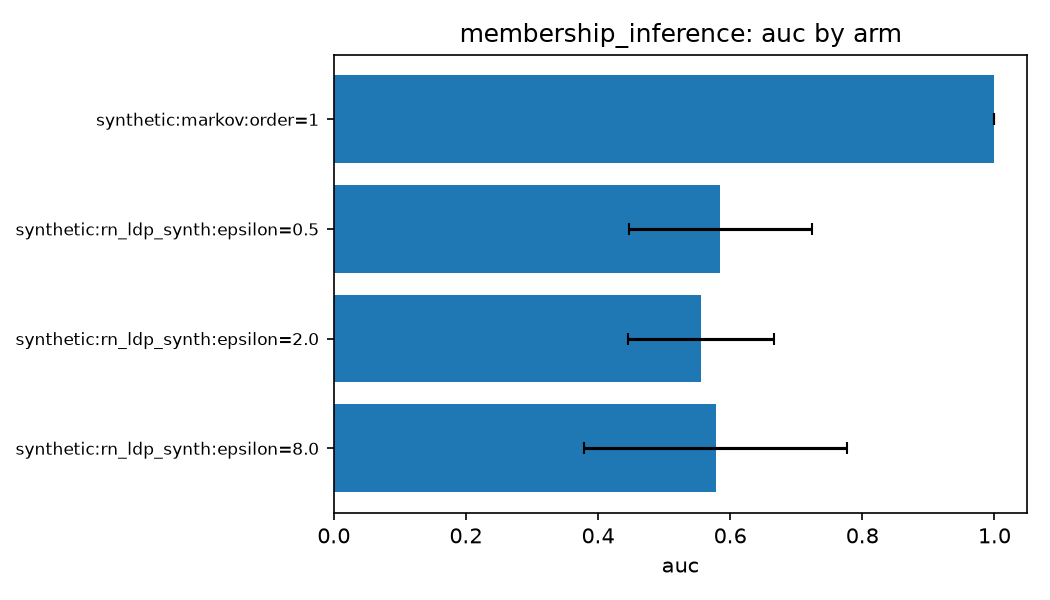

mechanisms_poi_inference.png


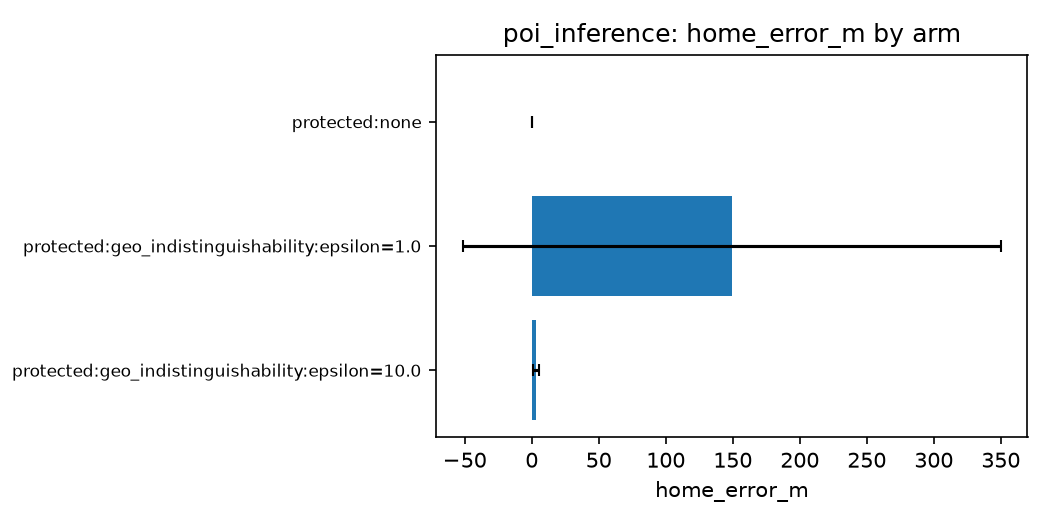

mechanisms_reconstruction.png


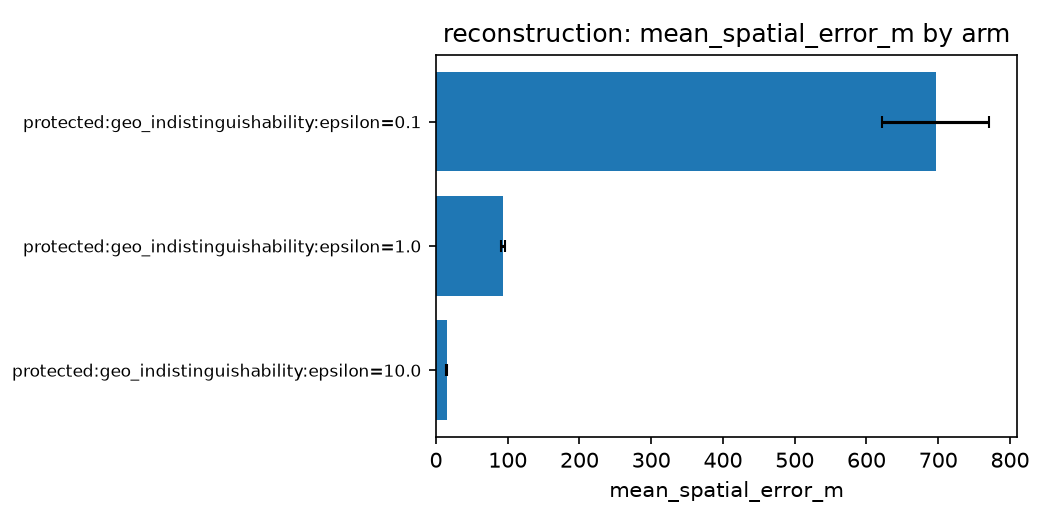

mechanisms_reidentification.png


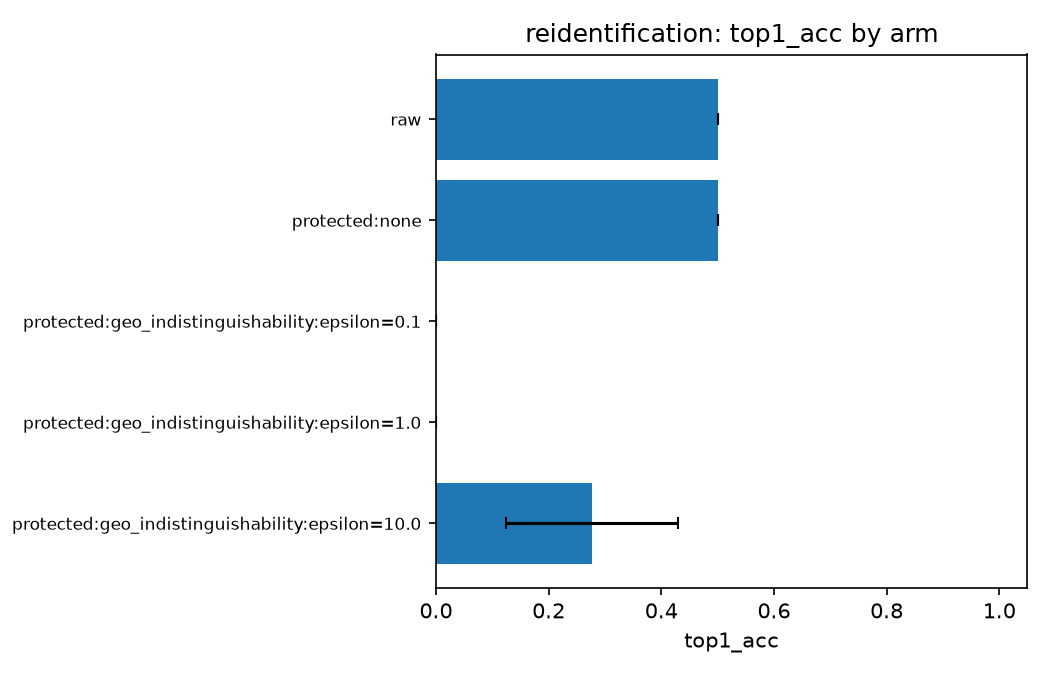

In [6]:
for path in plot_mechanisms(agg_rows, FIGURES_DIR):
    print(path.name)
    display(Image(filename=str(path)))

## 7 · Računski čas

Čas enega zagona napada (povprečje čez semena, logaritemska os, barva po
družini). Pozor: privzeto vklopljeno merjenje pomnilniške špice
(`metrics.memory`) čas napada približno podvoji — za časovno merodajne
primerjave poganjaj z `metrics: {memory: false}` (`docs/RUNNING.md` §7.3, R0).


runtime.png


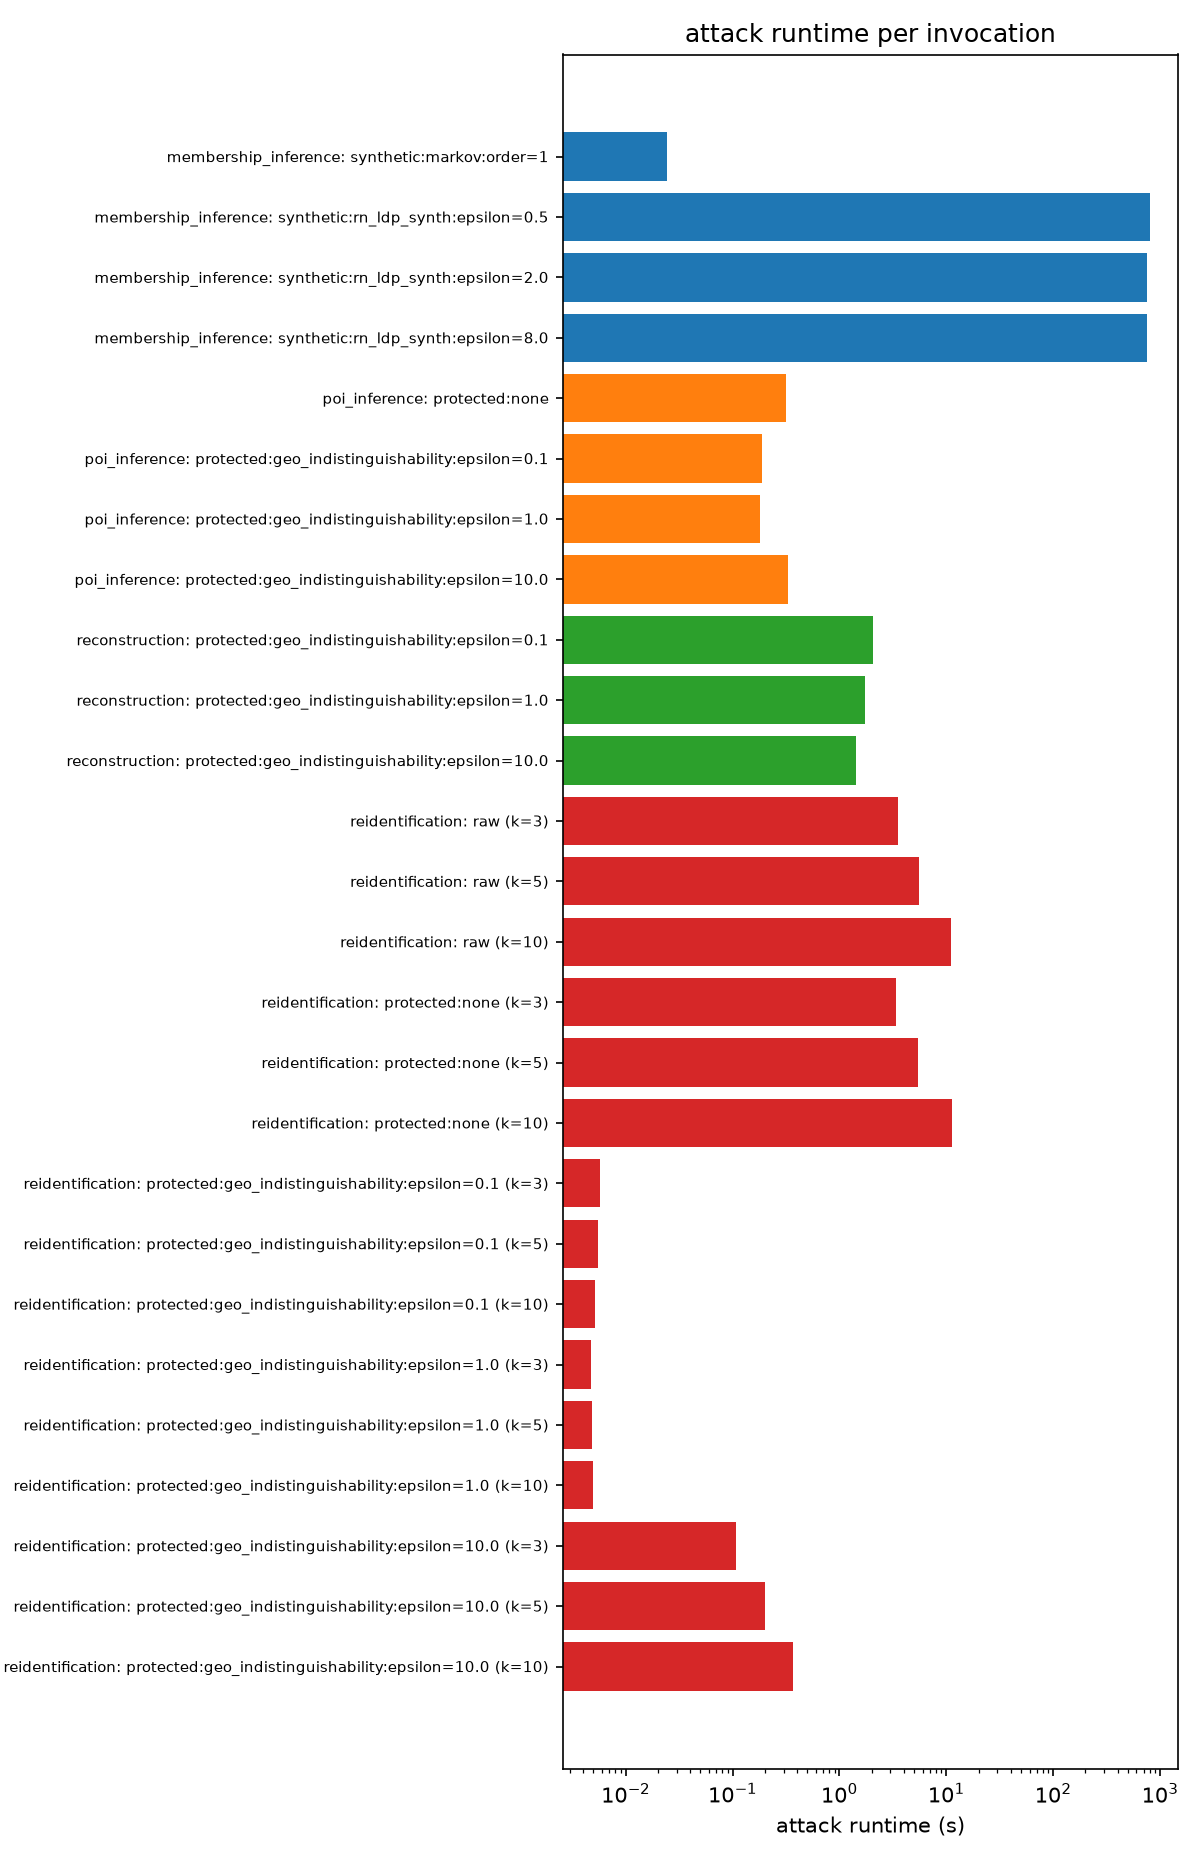

In [7]:
for path in plot_runtime(agg_rows, FIGURES_DIR):
    print(path.name)
    display(Image(filename=str(path)))

## 8 · Pregled računskega proračuna (X = 300 s)

Orkestrator vsako prekoračitev proračuna zabeleži v `run.json` (blok
`over_budget`); zagona nikoli ne prekine in rezultatov ne krči. Ta pregled
zbere prekoračitve iz vseh zagonov — uporabi ga pri načrtovanju *naslednjih*
zagonov kampanje po lestvi krčenja iz `docs/RUNNING.md` §7.3. Stolpec
`memory_traced` opozarja, da je bil čas izmerjen z vklopljenim sledenjem
pomnilnika in je zato napihnjen (pravilo R0).


In [8]:
import json

offenders = []
for run_json in sorted(RESULTS_DIR.rglob("run.json")):
    data = json.loads(run_json.read_text())
    block = data.get("over_budget") or {}
    for off in block.get("attacks", []):
        offenders.append(
            {
                "run": str(run_json.parent.relative_to(RESULTS_DIR)),
                "result_id": off["result_id"],
                "runtime_s": off["runtime_s"],
                "budget_s": block.get("budget_s"),
                "memory_traced": block.get("memory_traced"),
            }
        )
if offenders:
    display(pd.DataFrame(offenders).sort_values("runtime_s", ascending=False))
    print(
        "Lestev krcenja (docs/RUNNING.md, razdelek 7.3), korak za korakom:\n"
        " 1. dataset.max_users stopnjo nizje po lestvi 182 -> 100 -> 50 -> 20;\n"
        " 2. nato druzinski gumb: MIA prepolovi n_shadow (ne pod 8), "
        "reidentifikacija opusti najvecji known_points;\n"
        " 3. kar ostane nad proracunom, se iz kampanje izloci in izlocitev "
        "(z izmerjenim casom) zabelezi."
    )
else:
    print("Nobena invokacija napada ni prekoracila proracuna 300 s.")

,run,result_id,runtime_s,budget_s,memory_traced
0,geolife_synth_mia_u20\seed1,membership_inference:synthetic:rn_ldp_synth:ep...,866.294,300.0,False
3,geolife_synth_mia_u20\seed2,membership_inference:synthetic:rn_ldp_synth:ep...,765.345,300.0,False
6,geolife_synth_mia_u20\seed3,membership_inference:synthetic:rn_ldp_synth:ep...,761.925,300.0,False
4,geolife_synth_mia_u20\seed2,membership_inference:synthetic:rn_ldp_synth:ep...,761.781,300.0,False
5,geolife_synth_mia_u20\seed2,membership_inference:synthetic:rn_ldp_synth:ep...,760.570,300.0,False
1,geolife_synth_mia_u20\seed1,membership_inference:synthetic:rn_ldp_synth:ep...,759.128,300.0,False
7,geolife_synth_mia_u20\seed3,membership_inference:synthetic:rn_ldp_synth:ep...,758.257,300.0,False
2,geolife_synth_mia_u20\seed1,membership_inference:synthetic:rn_ldp_synth:ep...,755.186,300.0,False
8,geolife_synth_mia_u20\seed3,membership_inference:synthetic:rn_ldp_synth:ep...,755.122,300.0,False


Lestev krcenja (docs/RUNNING.md, razdelek 7.3), korak za korakom:
 1. dataset.max_users stopnjo nizje po lestvi 182 -> 100 -> 50 -> 20;
 2. nato druzinski gumb: MIA prepolovi n_shadow (ne pod 8), reidentifikacija opusti najvecji known_points;
 3. kar ostane nad proracunom, se iz kampanje izloci in izlocitev (z izmerjenim casom) zabelezi.


## 9 · Diagnostika praga ujemanja (S4-1)

Ta celica je podlaga za izbiro `map_matching.min_match_score` po odločitvi S4-1
(`docs/HANDOFF_S4_POPRAVKI.md` §1): populacija poročila so vozne sledi,
definirane operativno kot sledi z oceno ujemanja `match_score ≥ prag`, prag pa
se izbere iz izmerjene porazdelitve ocen, ne na slepo.

**Kaj celica dela.** Požene natanko produkcijski del cevovoda do ujemanja
(nalaganje → čiščenje → podvzorčenje na 20 uporabnikov → razrez → ujemanje na
vozno omrežje) prek istih funkcij kot orkestrator, le s pragom 0.0, tako da
vsaka očiščena sled obdrži svojo oceno. Rezultat se predpomni v
`data/processed/` pod svojim ključem različice, zato je ponovna izvedba
poceni. Napadov ne poganja in v `results/` ne piše ničesar.

**Kako brati izpis.** Histogram kaže porazdelitev ocen čez vse očiščene sledi;
tabela za vsak kandidatni prag pove, koliko sledi preživi, koliko od 20
uporabnikov pokrijejo, koliko nečlanov (razrez `test`) ostane za napad na
članstvo pri 20 uporabnikih in grobo projekcijo nečlanov pri polnem obsegu
182 uporabnikov (nečlani ≈ 0,2 × preživetje × 14 600 očiščenih sledi,
izpeljava v `docs/HANDOFF_S4_POPRAVKI.md` §S4-2). Merilo validacijskega
pogona (§2 istega dokumenta): pri 20 uporabnikih vsaj 11 nečlanov in
pokritih vsaj 15 od 20 uporabnikov.

Diagnostika teče na avtorjevem okolju (surovi Geolife podatki niso v
repozitoriju); izvedeni izpisi v tem zvezku so dokaz, na katerem temelji
izbrani prag.


In [9]:
import dataclasses
import logging

import matplotlib.pyplot as plt
import numpy as np

from trajguard.experiments.orchestrator import _matched_pool, _net_provider, load_config

logging.disable(logging.WARNING)  # silence leuven's linear-search notices

# The YAML's paths are relative to the repo root; this notebook runs in notebooks/.
ROOT = Path("..").resolve()
cfg = load_config(ROOT / "config" / "experiments" / "geolife_geoind_reid_u20.yaml")
cfg = dataclasses.replace(
    cfg,
    min_match_score=0.0,  # keep every cleaned trajectory so each retains its score
    output_dir=ROOT / cfg.output_dir,
    cache_dir=ROOT / cfg.cache_dir,
    protected_dir=ROOT / cfg.protected_dir,
    map_dir=ROOT / cfg.map_dir,
    dataset_path=ROOT / cfg.dataset_path,
)
matched, clean_by_id, _, split_counts = _matched_pool(cfg, _net_provider(cfg))
scores = pd.DataFrame(
    {
        "user_id": [m.user_id for m in matched],
        "match_score": [m.match_score for m in matched],
        "split": [clean_by_id[m.traj_id].split for m in matched],
    }
)
n_clean = len(scores)
n_users = scores["user_id"].nunique()
print(f"cleaned trajectories: {n_clean} from {n_users} users; splits: {split_counts}")

# Non-member projection at full scale, HANDOFF_S4_POPRAVKI.md §S4-2:
# non-members ~ test fraction (0.2) x survival rate x cleaned trajectories at 182 users.
# The 0.2 is the *user* fraction; the realised per-trace test share at 20 users is
# 142/1607 = 8.8 %, so the projection is an expectation, not a guarantee.
CLEANED_AT_182 = 14_600
TEST_FRACTION = cfg.fractions["test"]
candidate_thresholds = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
table = pd.DataFrame(
    {
        "prag": t,
        "prezivele sledi": int((scores["match_score"] >= t).sum()),
        "prezivetje %": round(100 * (scores["match_score"] >= t).mean(), 1),
        "pokriti uporabniki (od 20)": scores.loc[scores["match_score"] >= t, "user_id"].nunique(),
        "neclani (test) pri 20": int(
            ((scores["match_score"] >= t) & (scores["split"] == "test")).sum()
        ),
        "projekcija neclanov pri 182": round(
            TEST_FRACTION * (scores["match_score"] >= t).mean() * CLEANED_AT_182
        ),
    }
    for t in candidate_thresholds
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(scores["match_score"], bins=np.arange(0.0, 1.025, 0.025), color="#5B7DB1", zorder=2)
for t in candidate_thresholds:
    ax.axvline(t, color="#8A8A8A", linestyle="--", linewidth=1, zorder=3)
    ax.text(t, ax.get_ylim()[1] * 0.97, f"{t:g}", ha="center", va="top", fontsize=8, color="#555")
ax.set_xlabel("match_score")
ax.set_ylabel("stevilo ocisenih sledi")
ax.set_title(f"Porazdelitev match_score, geolife_geoind_reid_u20 (n = {n_clean})")
ax.grid(axis="y", color="#E3E3E3", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "match_score_diagnostic.png", dpi=150)
table

cleaned trajectories: 1607 from 20 users; splits: {'train': 556, 'shadow': 897, 'test': 142, 'attack': 12}


,prag,prezivele sledi,prezivetje %,pokriti uporabniki (od 20),neclani (test) pri 20,projekcija neclanov pri 182
0,0.05,236,14.7,16,15,429
1,0.10,171,10.6,15,10,311
2,0.15,141,8.8,14,8,256
3,0.20,125,7.8,14,7,227
4,0.30,92,5.7,12,4,167
5,0.40,78,4.9,11,3,142
6,0.50,64,4.0,11,3,116
7,0.60,45,2.8,9,3,82
8,0.70,20,1.2,7,2,36


## Kam naprej

- Nove zagone kampanje poganjaj s `trajguard repeat` (`docs/RUNNING.md` §7.1)
  in osveži ta zvezek headlessly (ukaz v uvodu).
- Rezultati na fixture podatkih (2 uporabnika, 8 poti) so statistično
  nepomembni — služijo samo kot dokaz, da vsak korak teče (`docs/RUNNING.md`
  §5). Za poročilo uporabi zagone na pravem Geolife naboru.
- Za prenos v Word: slike so v `reports/s4_figures/`, tabele izvoziš iz
  pandas (`DataFrame.to_csv` / `to_clipboard`), celoten zvezek pa z
  `uv run jupyter nbconvert --to html --no-input notebooks/03_s4_sweep.ipynb`.
